# Data Exploration

Explore raw CT volumes from the CT-RATE-AD dataset to understand their features which can help in deciding for the preprocessing pipeline. 

In this notebook, we can understand the raw ct-image file structure, shape, dtype, and HU ranges, voxel spacing and resolution. Also by visualizing some slices we check how the CT images looks. 

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

## 1. Load the Splited Label DF

Load the labels file which contains train/val/test split.

In [2]:
PROJECT_PATH = Path("/home/hpc/iwi5/iwi5437h/ct-anomaly-detection")
DATA_PATH = Path("/anvme/workspace/b180dc29-CT_RATE_IDEA_MIRROR")

# Load the splitted label file
df = pd.read_csv(PROJECT_PATH / "data" / "processed" / "labels_with_split.csv")

print(f"Total number of volumes: {len(df)}")
print(f"Columns of labels df: {df.columns.tolist()}")

print("\nFirst rows of the labels dataframe:")
df.head()

Total number of volumes: 49399
Columns of labels df: ['Predicted_label', 'VolumeName', 'Findings_EN', 'Impressions_EN', 'patient_id', 'scan_id', 'reconstruction', 'binary_label', 'split']

First rows of the labels dataframe:


,Predicted_label,VolumeName,Findings_EN,Impressions_EN,patient_id,scan_id,reconstruction,binary_label,split
0,2,train_1_a_1.nii.gz,Multiple venous collaterals are present in the...,Multiple venous collaterals in the anterior l...,train_1,a,1,1,test
1,2,train_1_a_2.nii.gz,Multiple venous collaterals are present in the...,Multiple venous collaterals in the anterior l...,train_1,a,2,1,test
2,2,train_2_a_1.nii.gz,Trachea and both main bronchi were in the midl...,Emphysematous and passive atelectatic changes...,train_2,a,1,1,train
3,2,train_2_a_2.nii.gz,Trachea and both main bronchi were in the midl...,Emphysematous and passive atelectatic changes...,train_2,a,2,1,train
4,2,train_3_a_1.nii.gz,Right thyroid lobe sizes increased. Evaluation...,Calcific atheromatous plaques in coronary art...,train_3,a,1,1,train


## 2. Volumes Path Construction

Define a function to get the path to .nii.gz file of any CSV row. 


In [3]:
def get_volume_path(data_path, patient_id, scan_id, volume_name):
    """
    Constructs the file path for a given volume based on the patient ID, scan ID, and volume name.

    Args:
        data_path: The base path to the data directory.
        patient_id: The unique identifier for the patient.
        scan_id: The unique identifier for the scan.      
        volume_name: The name of the volume (e.g., "volume.nii.gz").

    Returns:
        Volume_path: The constructed file path for the volume.
    """

    # Extract split from patient_id
    split = patient_id.split("_")[0]
    
    # Construct the related folders name
    patient_folder = f"{patient_id}"
    split_folder = f"CT-RATE_{split}_fixed"
    scan_folder = f"{patient_id}_{scan_id}"
    volume_folder = f"{volume_name}"
    
    Volume_path = data_path / split_folder / patient_folder / scan_folder / volume_folder

    return Volume_path

## 4. Load One Volume and Check its Properties

Load a sample volume and check its main properties: shape, dtype, HU range, and voxel spacing.

In [4]:
# Select one volume to explore
row = df.iloc[0]

path = get_volume_path(
    data_path=DATA_PATH,
    patient_id=row["patient_id"],
    scan_id=row["scan_id"],
    volume_name=row["VolumeName"]
)

# Load the volume
nii = nib.load(path)
volume = nii.get_fdata()

# Basic information about the volume
print(f"Volume name: {row['VolumeName']}")
print(f"Shape: {volume.shape}")
print(f"Dtype: {volume.dtype}")
print(f"Min HU: {volume.min():.2f}")
print(f"Max HU: {volume.max():.2f}")
print(f"Mean HU: {volume.mean():.2f}")

# Voxel spacing (Resolution)
zoom = nii.header.get_zooms()
print(f"Voxel spacing (mm): {zoom}")

Volume name: train_1_a_1.nii.gz
Shape: (512, 512, 303)
Dtype: float64
Min HU: -8192.00
Max HU: 8078.00
Mean HU: -1043.16
Voxel spacing (mm): (np.float32(0.8209062), np.float32(0.8209062), np.float32(1.0))


## 5. Visualize Slices

Plot slices at 25%, 50%, and 75% depth to visually check how a chest CT looks like.
Visualization uses the different HU clips:
- with no clipping
- with clipping: [-1000, +1000]
- with clipping: [-1000, +200]

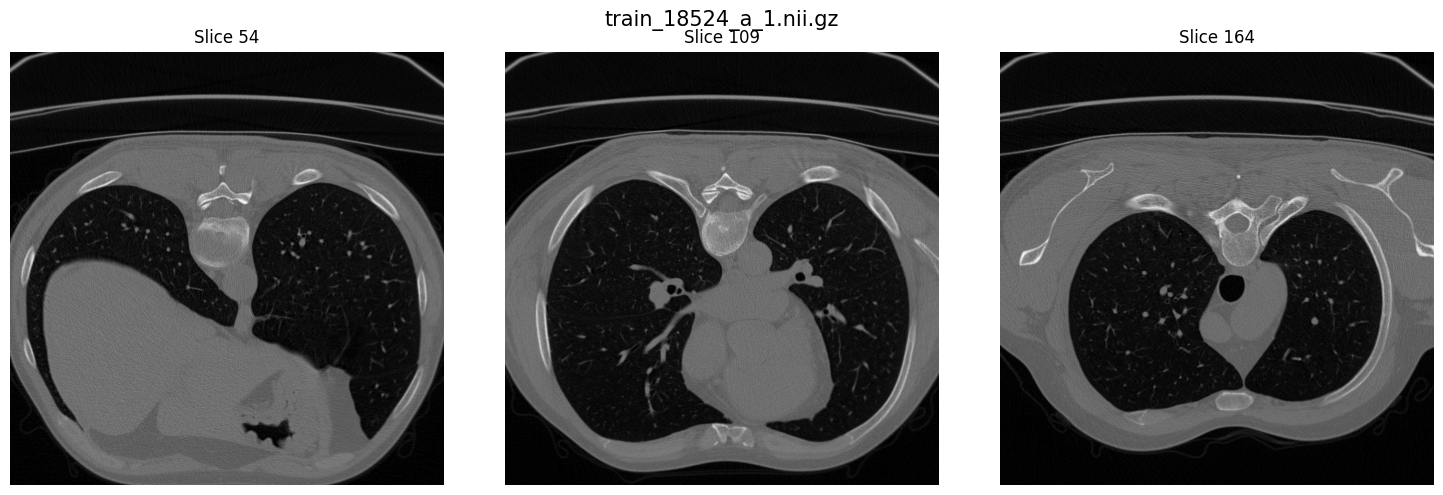

In [9]:
# Without clipping
# Visualize three axial slices: 25%, 50%, and 75% through the depth of the volume
depth = volume.shape[2]
slice_indices = [depth // 4, depth // 2, 3 * depth // 4]
slice_labels = ["25%", "50%", "75%"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(row['VolumeName'], fontsize=15)

for ax, idx, label in zip(axes, slice_indices, slice_labels):
    slice = volume[:, :, idx]
    ax.imshow(slice.T, cmap="gray", origin="lower")
    ax.set_title(f"Slice {idx}")
    ax.axis("off")

plt.tight_layout()

plt.savefig(PROJECT_PATH / "analysis" / "slice_visualization_no_clipping.png", dpi=150)
plt.show()

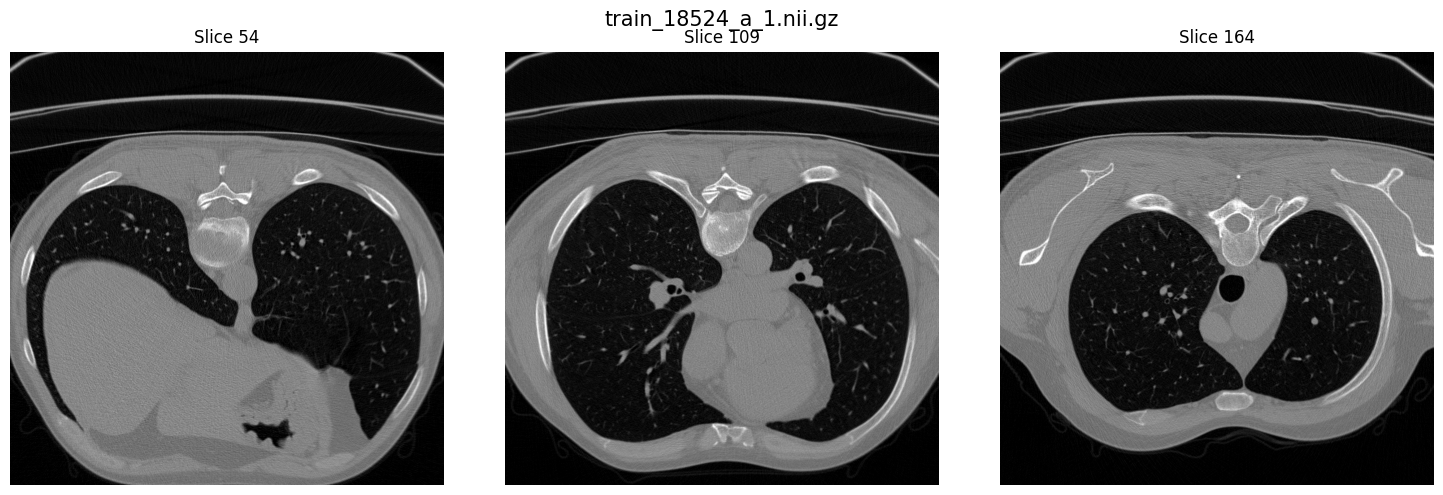

In [10]:
# With clipping to -1000 to 1000 HU
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(row['VolumeName'], fontsize=15)

for ax, idx, label in zip(axes, slice_indices, slice_labels):
    # Clip to standard lung window for visualization
    clipped_slice = np.clip(volume[:, :, idx], -1000, 1000)
    ax.imshow(clipped_slice.T, cmap="gray", origin="lower")
    ax.set_title(f"Slice {idx}")
    ax.axis("off")

plt.tight_layout()

plt.savefig(PROJECT_PATH / "analysis" / "slice_visualization_clipped_1000.png", dpi=150)
plt.show()

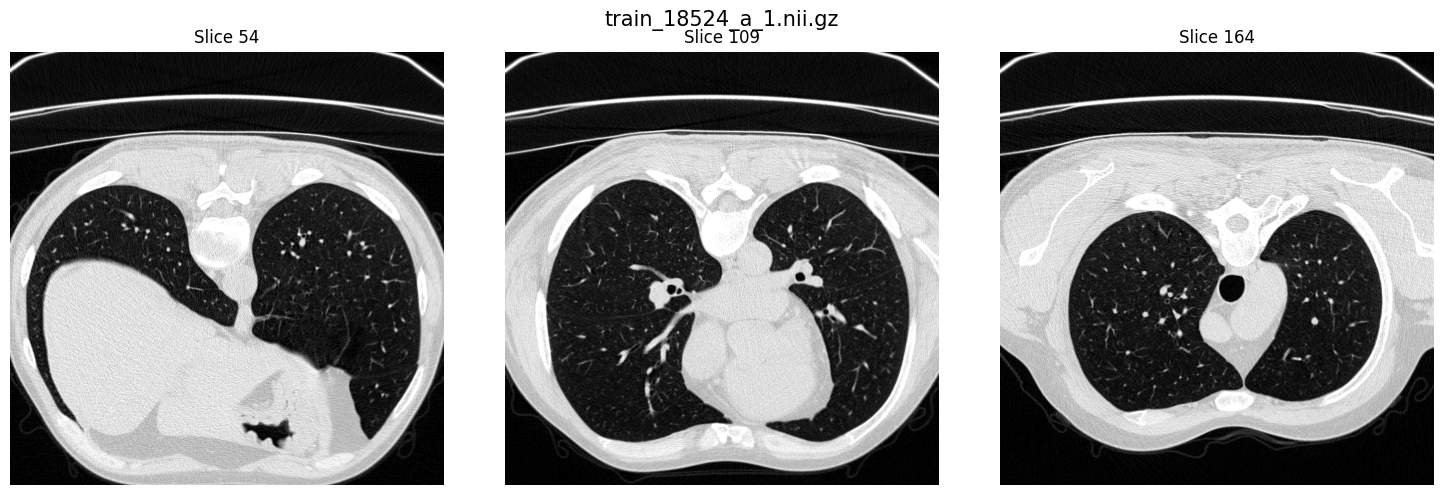

In [11]:
# With clipping to -1000 to 200 HU
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(row['VolumeName'], fontsize=15)

for ax, idx, label in zip(axes, slice_indices, slice_labels):
    # Clip to standard lung window for visualization
    clipped_slice = np.clip(volume[:, :, idx], -1000, 200)
    ax.imshow(clipped_slice.T, cmap="gray", origin="lower")
    ax.set_title(f"Slice {idx}")
    ax.axis("off")

plt.tight_layout()

plt.savefig(PROJECT_PATH / "analysis" / "slice_visualization_clipped_200.png", dpi=150)
plt.show()

## 6. Check Multiple Scans to Confirm Consistency

Sample 10 different scans to check whether shape, spacing, and HU range are consistent or vary across the dataset. 
This can help us to deciside for resampling steps later.

In [8]:
# Sample 10 scans
samples = df.sample(n=10, random_state=42)

# Create a list to store the extracted information for each sample volume
sample_data = []

for _, row in samples.iterrows():
    path = get_volume_path(
        data_path=DATA_PATH,
        patient_id=row["patient_id"],
        scan_id=row["scan_id"],
        volume_name=row["VolumeName"]
    )
    
    nii = nib.load(path)
    volume = nii.get_fdata()
    zooms = nii.header.get_zooms()
    
    # Round zooms for cleaner display
    rounded_zooms = tuple(round(float(z), 2) for z in zooms)
    
    # Append a dictionary for each row with the relevant information
    sample_data.append({
        "Volume": row["VolumeName"],
        "Shape": volume.shape,
        "Spacing (mm)": rounded_zooms,
        "Min HU": volume.min(),
        "Max HU": volume.max()
    })

# Convert list to DataFrame
sample_data = pd.DataFrame(sample_data)

sample_data

,Volume,Shape,Spacing (mm),Min HU,Max HU
0,train_6208_d_1.nii.gz,"(512, 512, 230)","(0.7, 0.7, 1.5)",-1024.0,3071.0
1,train_19036_a_2.nii.gz,"(512, 512, 427)","(0.68, 0.68, 0.75)",-1024.0,3071.0
2,train_9255_a_1.nii.gz,"(1024, 1024, 255)","(0.38, 0.38, 1.5)",-1024.0,3071.0
3,train_14797_b_1.nii.gz,"(512, 512, 211)","(0.76, 0.76, 1.5)",-1024.0,3071.0
4,train_11472_a_2.nii.gz,"(512, 512, 277)","(0.69, 0.69, 1.0)",-8192.0,4607.0
5,train_9537_a_1.nii.gz,"(512, 512, 174)","(0.74, 0.74, 1.5)",-1024.0,3015.0
6,train_3728_a_1.nii.gz,"(1024, 1024, 260)","(0.39, 0.39, 1.5)",-1024.0,3071.0
7,valid_1144_a_2.nii.gz,"(512, 512, 462)","(0.68, 0.68, 0.75)",-1024.0,3071.0
8,valid_224_a_1.nii.gz,"(1024, 1024, 245)","(0.38, 0.38, 1.5)",-1024.0,3071.0
9,train_18524_a_1.nii.gz,"(768, 768, 219)","(0.44, 0.44, 1.5)",-1024.0,1786.0
